#### **How does dynamic delta hedging error change with the discrete time intervals between hedge adjustments? How does this trade-off with transaction costs?**

In [32]:
import sys
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
from black_scholes import BlackScholes
from delta_hedging import discrete_delta_hedge

In theory, a continuously rebalanced delta hedge can replicate the option exactly under the Black-Scholes model assumptions. So if you hedge perfectly and continuously, there is no leftover profit or loss from the hedge itself.
<br><br>
In practice however, you can only rebalance at discrete times. Between hedge dates, the stock moves and the option’s delta changes, but your stock position is still based on the old delta. That mismatch means the hedge is no longer exact.
<br><br>
The hedging error is the final residual value of the hedged position after the option has expired and the hedge has been unwound. Below we run $100$ simulations of a full 1 year stock price path, with re-hedging every 5 days. For ease of comparison, we express the hedging error as a percentage of the initial value of the option at $t_0$.

In [33]:
hedge_pnls = discrete_delta_hedge(
    call=True,
    n_sims=100,
    S0=100,
    K=100,
    r=0.05,
    vol=0.2,
    T=1,
    dt=1/252,
    hedging_interval=5
)

print(f"Mean absolute hedging error as a % of initial option value (hedge adjustment every 5 days): {round(np.mean(abs(np.array(hedge_pnls))), 2)}%")

Mean absolute hedging error as a % of initial option value (hedge adjustment every 5 days): 0.39%


It is important to consider the standard deviation of the hedging error rather than purely its expectation, because across thousands of paths, you may for example find
$$
E[H] = 0
$$
$$
\operatorname{SD}(H) = 2.
$$
Where $H$ is the hedging error. This would mean the strategy is approximately unbiased on average, but individual hedges can still produce meaningful gains or losses.
<br><br>
Below we measure the effect of varying discrete intervals between hedges on the hedging error.

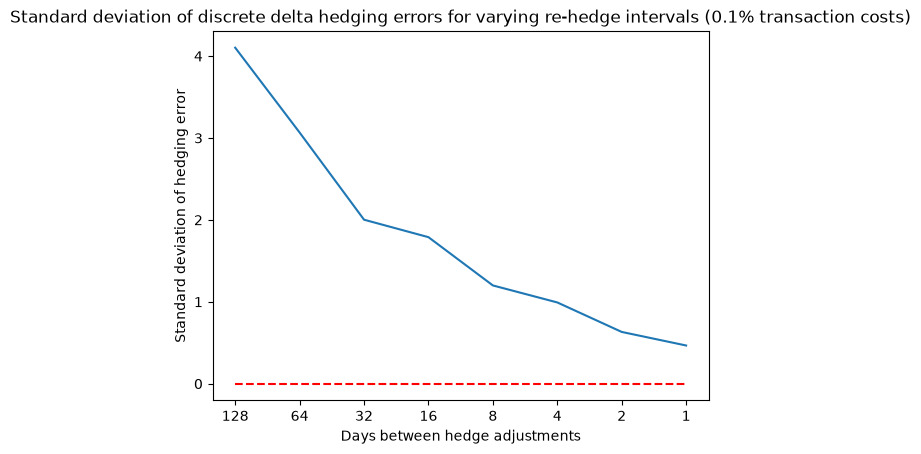

In [34]:
hedging_intervals = [128, 64, 32, 16, 8, 4, 2, 1]

mean_hedging_errors = []
std_hedging_errors = []
rmse_hedging_errors = []
mean_trading_costs = []

for interval in hedging_intervals:
    hedge_pnls, trading_costs = discrete_delta_hedge(
        call=True,
        n_sims=200,
        S0=100,
        K=100,
        r=0.05,
        vol=0.2,
        T=1,
        dt=1/252,
        hedging_interval=interval,
        trading_cost_prop=0.001
    )

    mean_hedging_errors.append(np.mean(hedge_pnls))
    std_hedging_errors.append(np.std(hedge_pnls))
    rmse_hedging_errors.append(np.sqrt(np.mean(np.array(hedge_pnls)**2)))
    mean_trading_costs.append(np.mean(trading_costs))


plt.figure()
plt.plot([str(i) for i in hedging_intervals], std_hedging_errors)
plt.title("Standard deviation of discrete delta hedging errors for varying re-hedge intervals (0.1% transaction costs)")
plt.xlabel("Days between hedge adjustments")
plt.ylabel("Standard deviation of hedging error")
plt.plot([str(i) for i in hedging_intervals], np.zeros(len(hedging_intervals)), c='r', linestyle='--')
plt.show()

As expected, in general, our hedging error decreases as we increase the frequency of hedge adjustments. However, we must also consider the impact of hedge frequency on transaction costs:

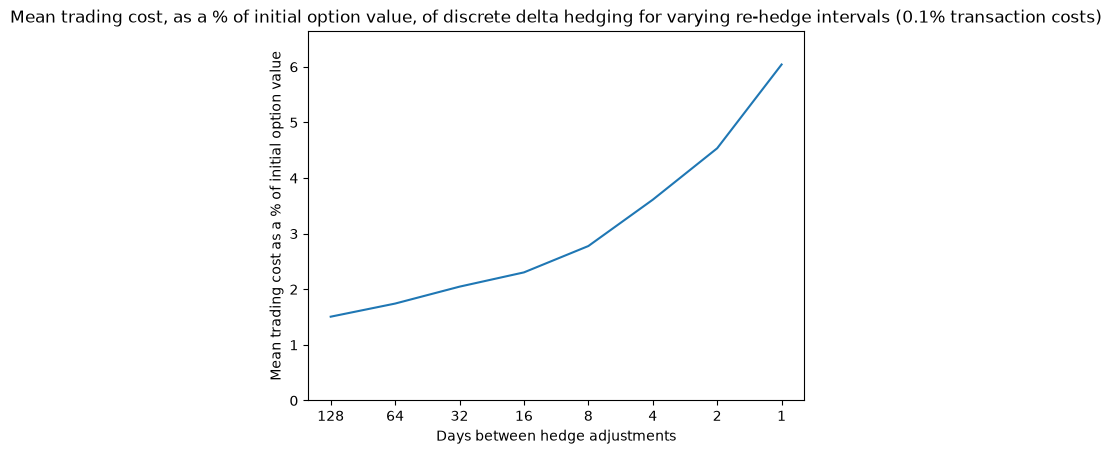

In [35]:
plt.figure()
plt.plot([str(i) for i in hedging_intervals], mean_trading_costs)
plt.title("Mean trading cost, as a % of initial option value, of discrete delta hedging for varying re-hedge intervals (0.1% transaction costs)")
plt.xlabel("Days between hedge adjustments")
plt.ylabel("Mean trading cost as a % of initial option value")
plt.ylim(0, max(mean_trading_costs) * 1.1)
plt.show()

While standard deviation is a good proxy for the spread of our hedging error around its mean, factoring in transaction costs creates a mean hedging error that is usually negative. We are more interested in the spread of our errors around our best case scenario, zero. 
<br><br>
The trade-off between the proximity to zero of the mean hedging error and its variance is analagous to a classic "bias-variance tradeoff", as increasing hedging frequency brings the mean further below zero due to transaction costs, but decreases the variance of our hedging error.
<br><br>
Root Mean Squared Error (RMSE) offers a clean way to visualise this trade-off experienced when increasing hedging frequency, as
$$
\operatorname{RMSE} = \sqrt{\underbrace{\operatorname{Var}(H)}_{\text{discrete hedging risk}} + \underbrace{\left(E[H]\right)^2}_{\text{transaction cost bias}^2}}
$$

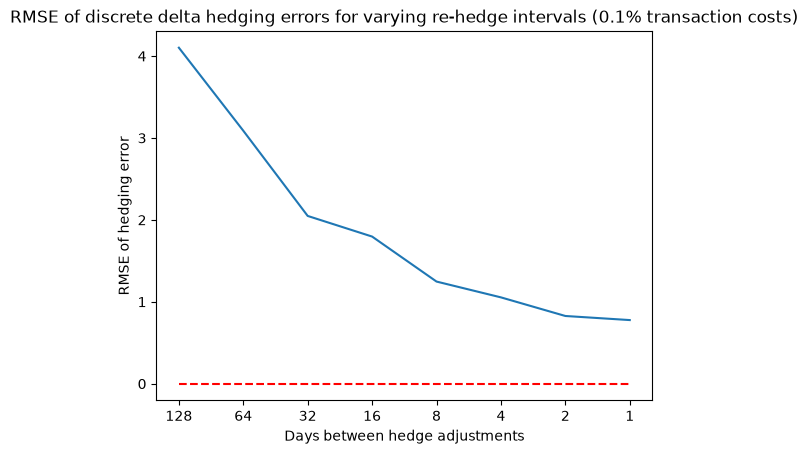

In [36]:
plt.figure()
plt.plot([str(i) for i in hedging_intervals], rmse_hedging_errors)
plt.title("RMSE of discrete delta hedging errors for varying re-hedge intervals (0.1% transaction costs)")
plt.xlabel("Days between hedge adjustments")
plt.ylabel("RMSE of hedging error")
plt.plot([str(i) for i in hedging_intervals], np.zeros(len(hedging_intervals)), c='r', linestyle='--')
plt.show()

This result appears to suggest that more frequent hedge adjustments are optimal, even with transaction costs. However, this simulation was done assuming 0.1% transaction costs. Let's perform the same investigation with higher transaction costs, 0.5%:

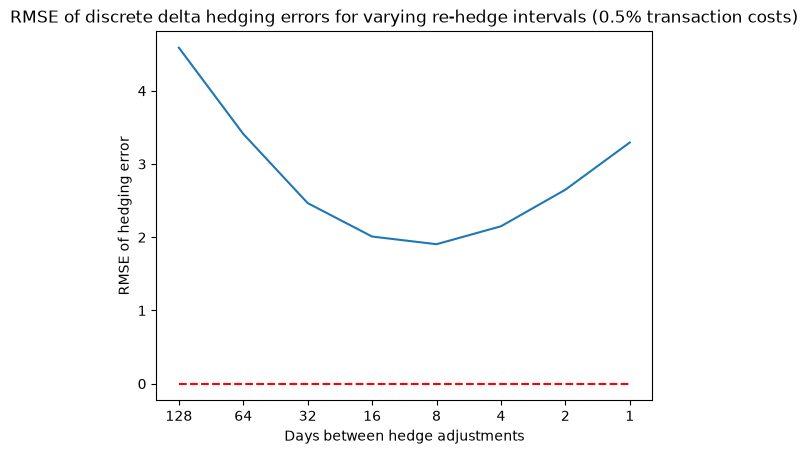

In [37]:
hedging_intervals = [128, 64, 32, 16, 8, 4, 2, 1]

mean_hedging_errors = []
std_hedging_errors = []
rmse_hedging_errors = []
mean_trading_costs = []

for interval in hedging_intervals:
    hedge_pnls, trading_costs = discrete_delta_hedge(
        call=True,
        n_sims=200,
        S0=100,
        K=100,
        r=0.05,
        vol=0.2,
        T=1,
        dt=1/252,
        hedging_interval=interval,
        trading_cost_prop=0.005
    )

    mean_hedging_errors.append(np.mean(hedge_pnls))
    std_hedging_errors.append(np.std(hedge_pnls))
    rmse_hedging_errors.append(np.sqrt(np.mean(np.array(hedge_pnls)**2)))
    mean_trading_costs.append(np.mean(trading_costs))


plt.figure()
plt.plot([str(i) for i in hedging_intervals], rmse_hedging_errors)
plt.title("RMSE of discrete delta hedging errors for varying re-hedge intervals (0.5% transaction costs)")
plt.xlabel("Days between hedge adjustments")
plt.ylabel("RMSE of hedging error")
plt.plot([str(i) for i in hedging_intervals], np.zeros(len(hedging_intervals)), c='r', linestyle='--')
plt.show()

In this higher transaction costs case, we can see that more frequent hedging is only better up to a certain point. After that, it becomes expensive, introducing stronger negative bias to the P&L.